In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt

C:\Users\noton\anaconda3\envs\env1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 5

data = pd.read_csv('data/data_AuCd2.csv')
y = pd.DataFrame(data['Class'], columns=['Class'])
X = data.drop(columns=['Sample_name', 'ratio_AuCd', 'H', 'V', 'C', 'ratio_AuCd', 'Class'])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
param_grid = {'max_depth': [4, 6], 'max_leaf_nodes': [3, 7, 11], 'l2_regularization': [0, 0.1, 1], 'min_samples_leaf': [3, 5]}
clf = GridSearchCV(HistGradientBoostingClassifier(random_state=0, max_bins=51),
                   param_grid=param_grid, scoring='accuracy', cv=10, n_jobs=12)
clf.fit(X_train,y_train['Class'])
clf_best = clf.best_estimator_
y_pred = clf_best.predict(X)
data['y_pred'] = y_pred
y_pred1 = clf_best.predict(X_train)
y_pred2 = clf_best.predict(X_test)

print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        23
           1       0.71      1.00      0.83         5

    accuracy                           0.93        28
   macro avg       0.86      0.96      0.89        28
weighted avg       0.95      0.93      0.93        28



In [4]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        88
           1       0.91      1.00      0.95        21

    accuracy                           0.98       109
   macro avg       0.96      0.99      0.97       109
weighted avg       0.98      0.98      0.98       109



In [5]:
explainer = shap.TreeExplainer(clf_best)
shap_values = explainer(X)

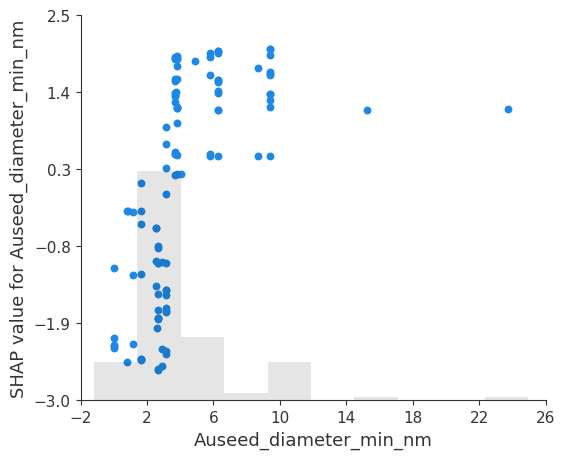

In [6]:
target = 'Auseed_diameter_min_nm'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-2, 26)
plt.ylim(-3, 2.5)
plt.xticks(range(-2, 27, 4))
plt.yticks(np.arange(-3, 2.6, 1.1))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

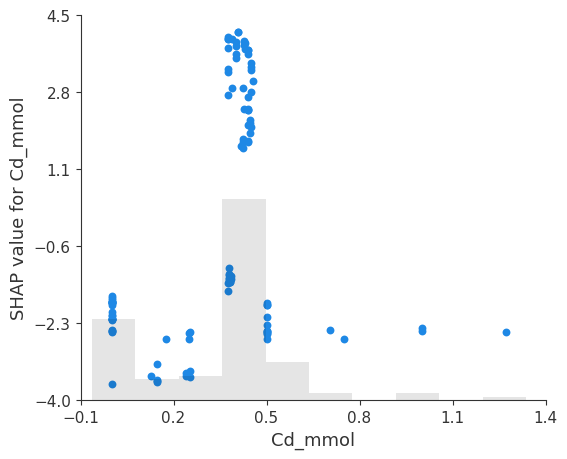

In [7]:
target = 'Cd_mmol'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-0.1, 1.4)
plt.ylim(-4, 4.5)
plt.xticks(np.arange(-0.1, 1.5, 0.3))
plt.yticks(np.arange(-4, 4.6, 1.7))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

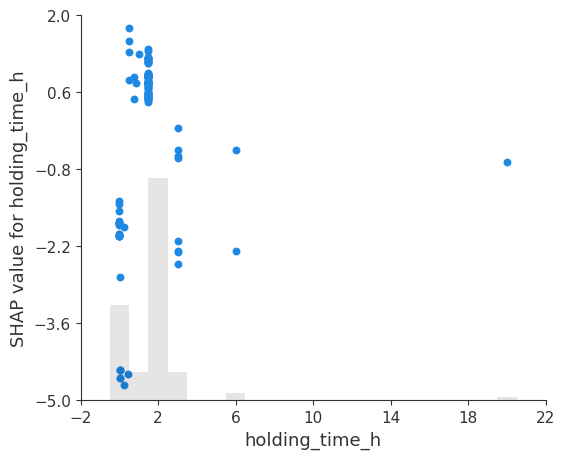

In [8]:
target = 'holding_time_h'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-2, 22)
plt.ylim(-5, 2)
plt.xticks(range(-2, 23, 4))
plt.yticks(np.arange(-5, 2.1, 1.4))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

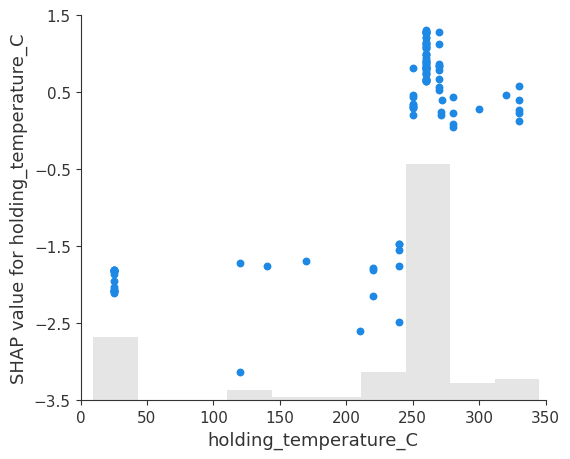

In [9]:
target = 'holding_temperature_C'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(0, 350)
plt.ylim(-3.5, 1.5)
plt.yticks(np.arange(-3.5, 1.6, 1))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

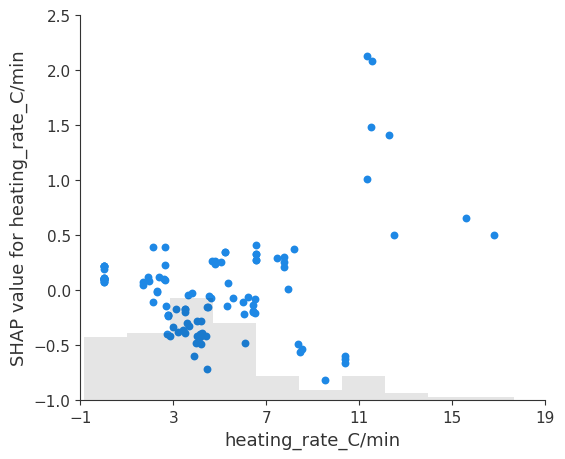

In [10]:
target = 'heating_rate_C/min'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-1, 19)
plt.ylim(-1, 2.5)
plt.xticks(range(-1, 20, 4))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_heating_rate_C_min_{seed}.pdf')

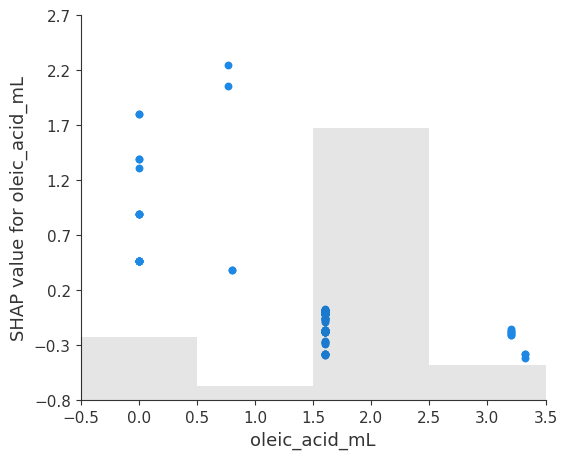

In [11]:
target = 'oleic_acid_mL'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-0.5, 3.5)
plt.ylim(-0.8, 2.7)
plt.yticks(np.arange(-0.8, 2.8, 0.5))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

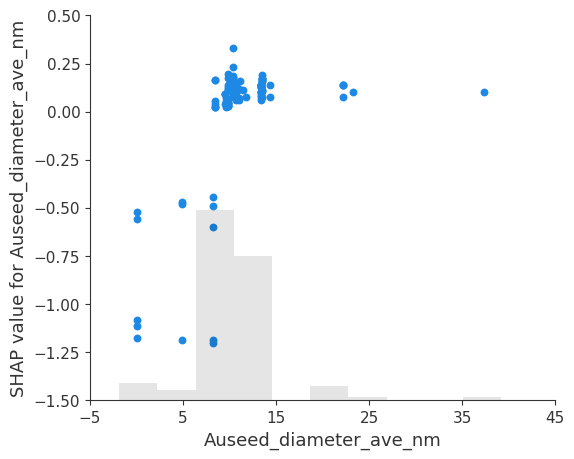

In [12]:
target = 'Auseed_diameter_ave_nm'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-5, 45)
plt.ylim(-1.5, 0.5)
plt.xticks(range(-5, 46, 10))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

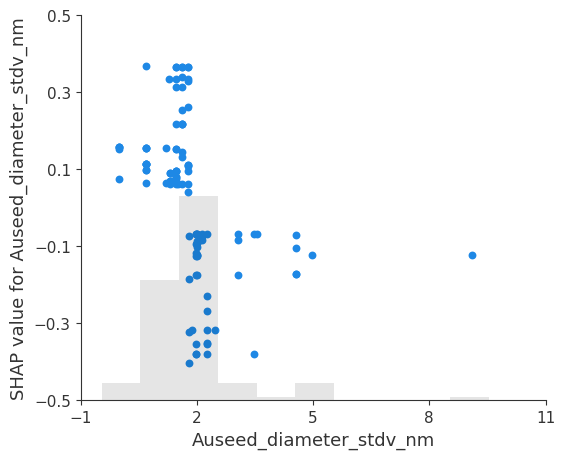

In [13]:
target = 'Auseed_diameter_stdv_nm'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-1, 11)
plt.ylim(-0.5, 0.5)
plt.xticks(range(-1, 12, 3))
plt.yticks(np.arange(-0.5, 0.6, 0.2))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

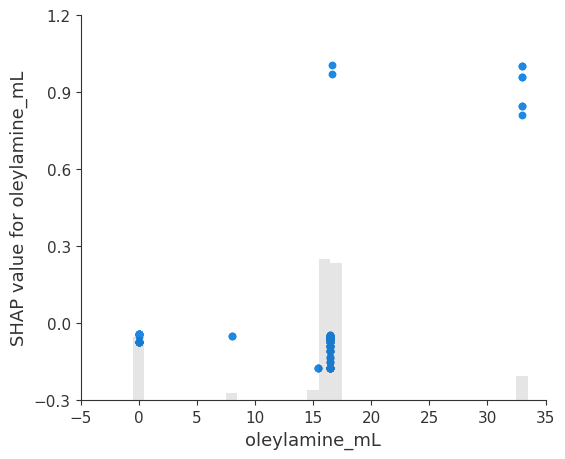

In [14]:
target = 'oleylamine_mL'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-5, 35)
plt.ylim(-0.3, 1.2)
plt.xticks(range(-5, 36, 5))
plt.yticks(np.arange(-0.3, 1.3, 0.3))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

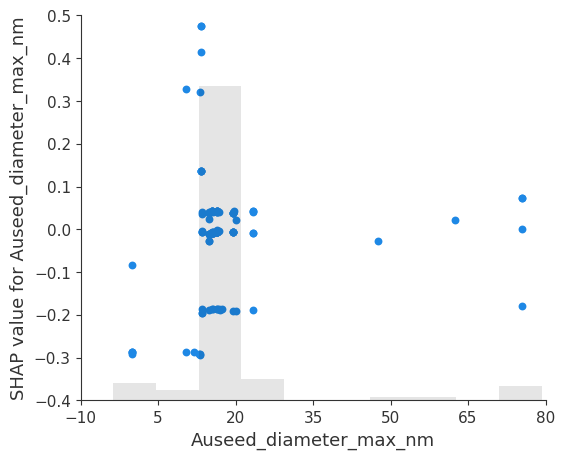

In [15]:
target = 'Auseed_diameter_max_nm'
shap.plots.scatter(shap_values[:, target], dot_size=32, show=False)
plt.xlim(-10, 80)
plt.ylim(-0.4, 0.5)
plt.xticks(range(-10, 81, 15))
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'result/SHAP/scatter_{target}_{seed}.pdf')

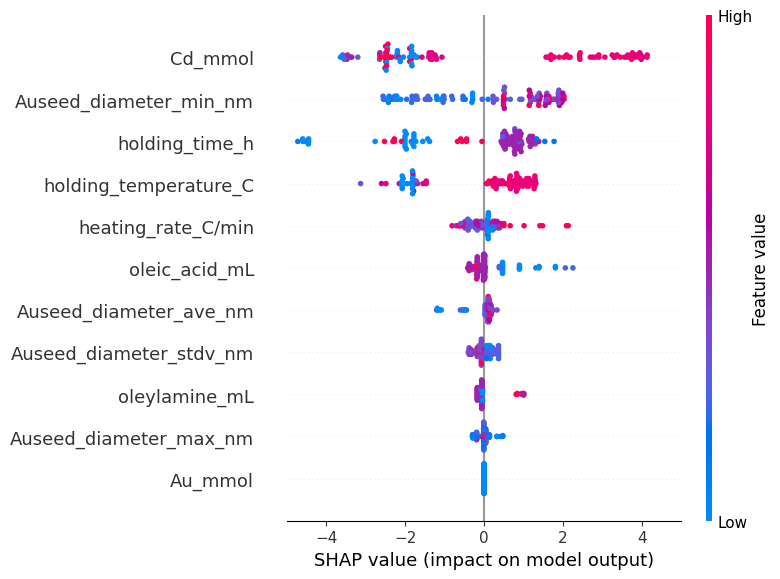

In [16]:
shap.summary_plot(shap_values, show=False)
plt.xlim(-5, 5)
plt.savefig(f'result/SHAP/summary_{seed}.pdf')

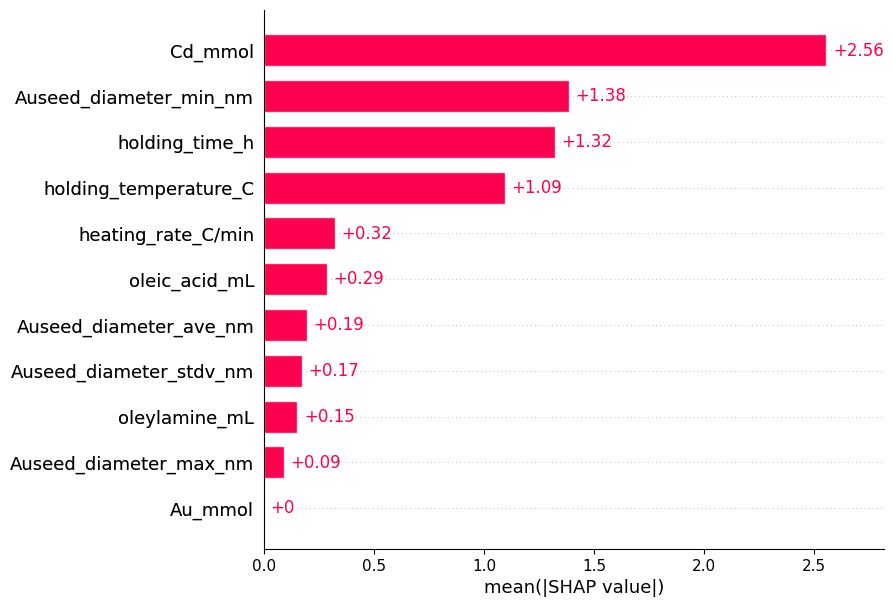

In [17]:
shap.plots.bar(shap_values, show=False, max_display=11)
plt.savefig(f'result/SHAP/bar_{seed}.pdf')

23
Sample_name                sam269_1.5h
Auseed_diameter_ave_nm         9.79022
Auseed_diameter_stdv_nm       1.462095
Auseed_diameter_max_nm       16.467147
Auseed_diameter_min_nm        3.702047
Au_mmol                           0.25
Cd_mmol                       0.375056
oleylamine_mL                     16.5
oleic_acid_mL                      1.6
heating_rate_C/min            2.629931
holding_temperature_C              260
holding_time_h                     1.5
ratio_AuCd                       100.0
H                                    Y
V                                  8.5
C                                  3.5
Class                                1
y_pred                               1
Name: 23, dtype: object


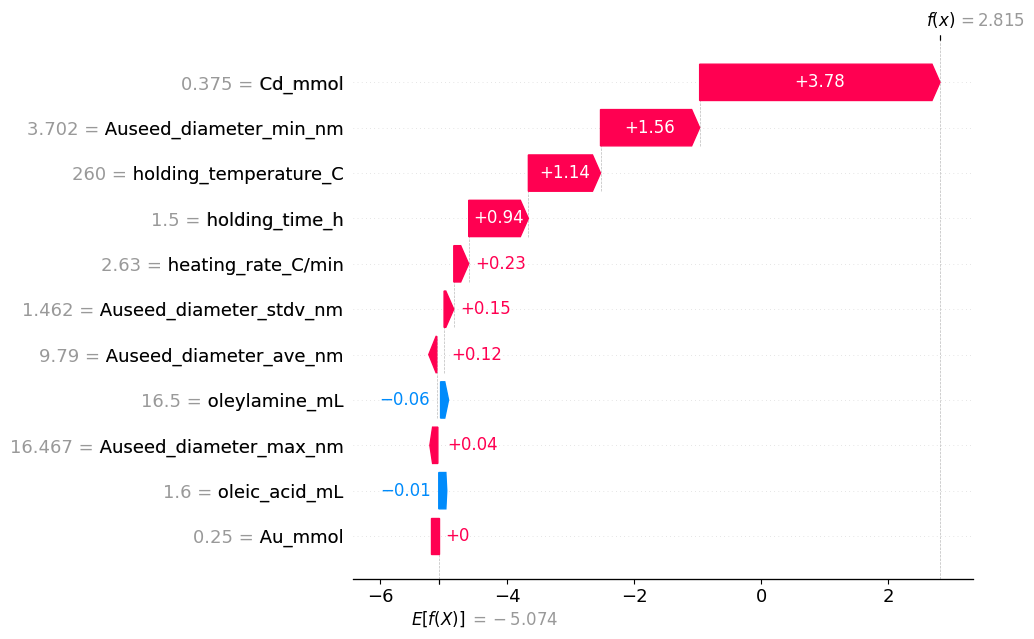

4
Sample_name                sam255_3h
Auseed_diameter_ave_nm          13.4
Auseed_diameter_stdv_nm          1.3
Auseed_diameter_max_nm     16.500476
Auseed_diameter_min_nm      2.689001
Au_mmol                          0.5
Cd_mmol                     0.501256
oleylamine_mL                   33.0
oleic_acid_mL                    3.2
heating_rate_C/min          4.142857
holding_temperature_C            270
holding_time_h                   3.0
ratio_AuCd                       0.0
H                                 RP
V                                3.5
C                                3.5
Class                              0
y_pred                             0
Name: 4, dtype: object


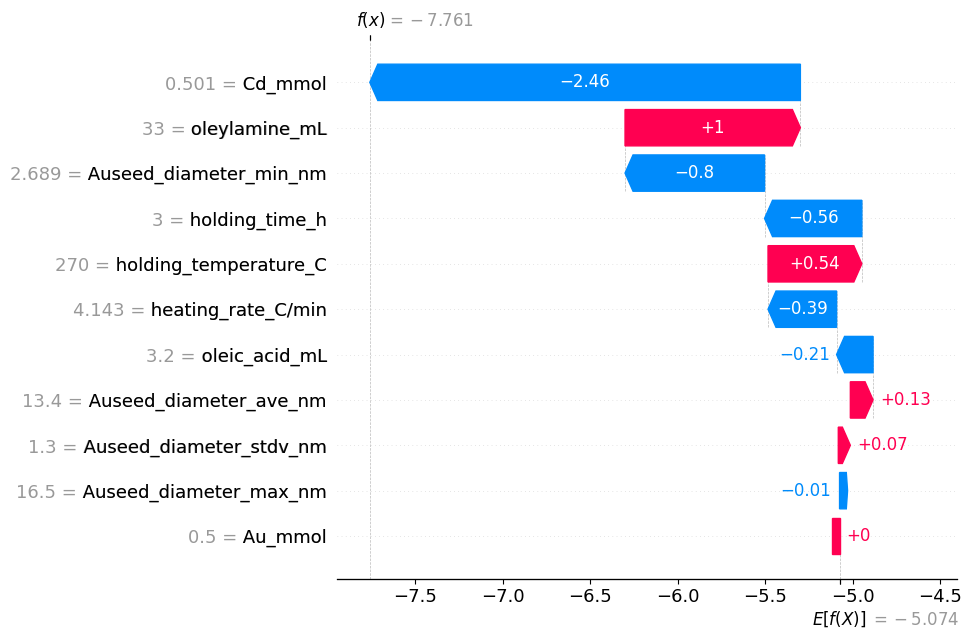

84
Sample_name                sam409_45 min
Auseed_diameter_ave_nm          8.419897
Auseed_diameter_stdv_nm         2.272716
Auseed_diameter_max_nm         13.235748
Auseed_diameter_min_nm          1.616775
Au_mmol                           0.2594
Cd_mmol                         0.447492
oleylamine_mL                      15.46
oleic_acid_mL                       3.32
heating_rate_C/min              10.37594
holding_temperature_C                280
holding_time_h                      0.75
ratio_AuCd                           0.0
H                                     YR
V                                    7.4
C                                   10.7
Class                                  0
y_pred                                 0
Name: 84, dtype: object


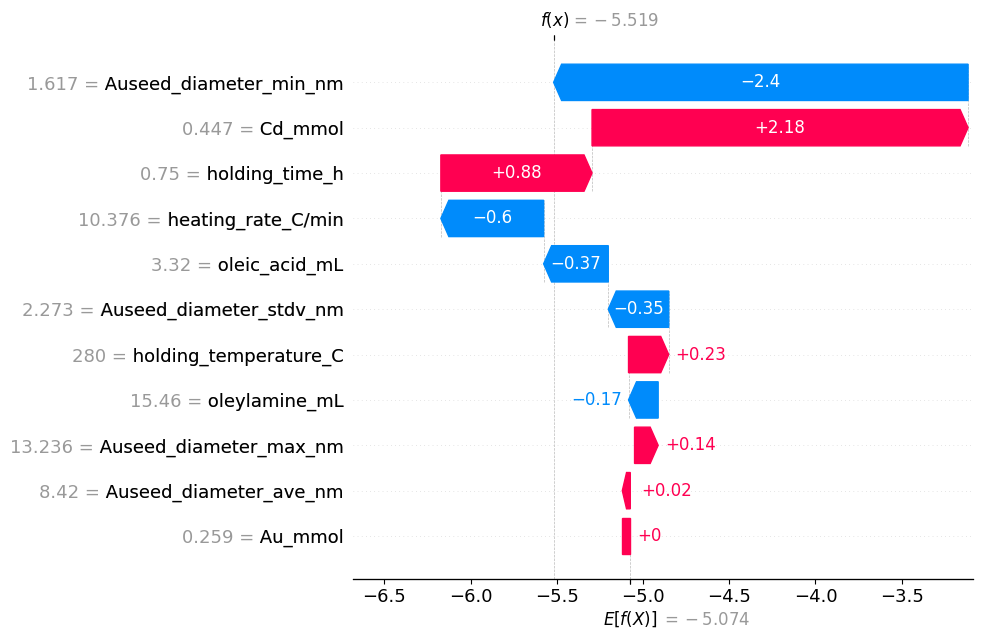

63
Sample_name                   sam389
Auseed_diameter_ave_nm     10.418418
Auseed_diameter_stdv_nm     1.771879
Auseed_diameter_max_nm     15.529712
Auseed_diameter_min_nm      3.832172
Au_mmol                         0.25
Cd_mmol                     1.273904
oleylamine_mL                   16.5
oleic_acid_mL                    1.6
heating_rate_C/min          4.508108
holding_temperature_C            270
holding_time_h                   1.5
ratio_AuCd                       0.0
H                                  Y
V                                9.2
C                                1.5
Class                              0
y_pred                             0
Name: 63, dtype: object


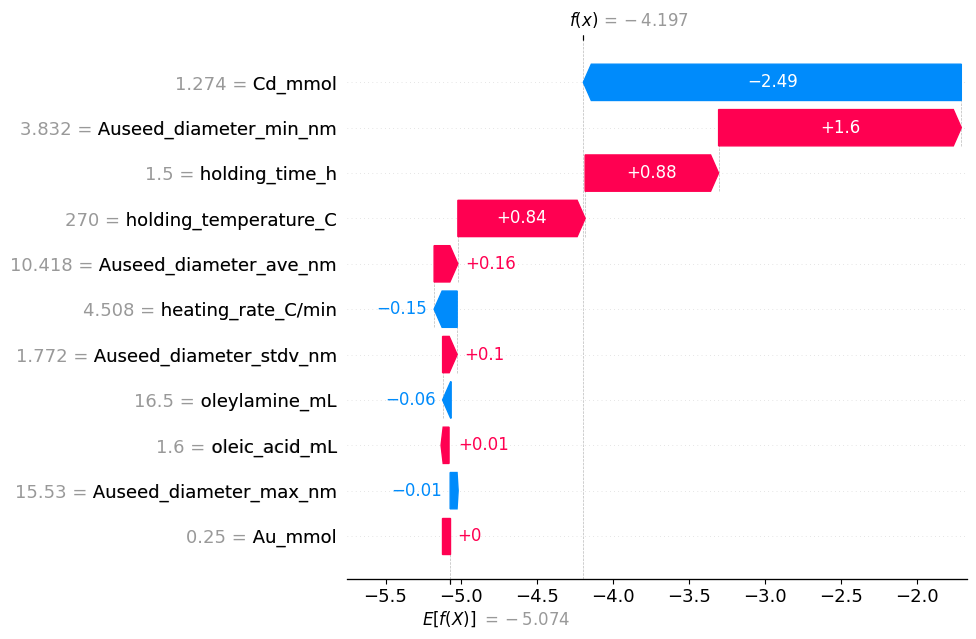

In [18]:
entry_list = [23, 4, 84, 63]
for entry in entry_list:
    print(entry)
    print(data.iloc[entry])
    fig = plt.figure()
    shap.plots.waterfall(shap_values[entry], max_display=11)
    fig.savefig(f'result/SHAP/waterfall_{entry}_{seed}.pdf')